In [1]:
!pip install folktables fairlearn shap matplotlib seaborn scikit-learn pandas numpy

                                              0.0/251.6 kB ? eta -:--:--
     --------------                          92.2/251.6 kB 2.6 MB/s eta 0:00:01
     ----------------------------------     225.3/251.6 kB 2.8 MB/s eta 0:00:01
     -------------------------------------- 251.6/251.6 kB 2.2 MB/s eta 0:00:00
                                              0.0/554.9 kB ? eta -:--:--
     --------------                         204.8/554.9 kB 6.3 MB/s eta 0:00:01
     ------------------------------         440.3/554.9 kB 5.5 MB/s eta 0:00:01
     -------------------------------------- 554.9/554.9 kB 5.0 MB/s eta 0:00:00
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
                                              0.0/294.9 kB ? eta -:--:--
     ------------------------------------   286.7/294.9 kB 8.9 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 6.1 MB/s eta 0:00:00
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
  Us


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from folktables import ACSDataSource, ACSIncome
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import shap
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
)
from fairlearn.postprocessing import ThresholdOptimizer

print("All imports successful!")

All imports successful!


In [3]:
years = [2014, 2018, 2022]
datasets = {}

for year in years:
    print(f"Downloading ACS data for {year}...")
    data_source = ACSDataSource(survey_year=str(year), horizon='1-Year', survey='person')
    acs_data = data_source.get_data(download=True)  # all states
    features, labels, group = ACSIncome.df_to_numpy(acs_data)
    
    # Get feature names from ACSIncome definition
    feature_names = [
        'AGEP',    # Age
        'COW',     # Class of worker
        'SCHL',    # Educational attainment
        'MAR',     # Marital status
        'OCCP',    # Occupation code
        'POBP',    # Place of birth
        'RELP',    # Relationship
        'WKHP',    # Hours worked per week
        'SEX',     # Sex (1=Male, 2=Female)
        'RAC1P',   # Race
    ]
    
    df = pd.DataFrame(features, columns=feature_names)
    df['income_over_50k'] = labels.astype(int)
    df['SEX_label'] = df['SEX'].map({1: 'Male', 2: 'Female'})
    
    datasets[year] = df
    print(f"  {year}: {len(df)} records loaded")

print("\nDone! All datasets loaded.")

  2014: 1587856 records loaded

data\2018\1-Year\csv_pvt.zip may be corrupted. Please try deleting it and rerunning this command.

Exception:  ('Connection broken: IncompleteRead(262144 bytes read, 1077009 more expected)', IncompleteRead(262144 bytes read, 1077009 more expected))


FileNotFoundError: [Errno 2] No such file or directory: 'data\\2018\\1-Year\\psam_p50.csv'

In [4]:
import os

for year in [2014, 2018, 2022]:
    path = f'data/{year}/1-Year'
    if os.path.exists(path):
        files = [f for f in os.listdir(path) if f.endswith('.csv')]
        print(f"{year}: {len(files)} CSV files found")
    else:
        print(f"{year}: folder not found")

2014: 51 CSV files found
2018: 50 CSV files found
2022: folder not found


In [5]:
# All expected state codes
all_states = [
    'p01','p02','p04','p05','p06','p08','p09','p10','p11','p12',
    'p13','p15','p16','p17','p18','p19','p20','p21','p22','p23',
    'p24','p25','p26','p27','p28','p29','p30','p31','p32','p33',
    'p34','p35','p36','p37','p38','p39','p40','p41','p42','p44',
    'p45','p46','p47','p48','p49','p50','p51','p53','p54','p55','p56'
]

path_2018 = 'data/2018/1-Year'
existing = set(os.listdir(path_2018))
expected = set(f'psam_{code}.csv' for code in all_states)
missing = expected - existing
print(f"Missing from 2018: {missing}")

Missing from 2018: {'psam_p11.csv', 'psam_p50.csv'}


In [6]:
from folktables import ACSDataSource, ACSIncome
import pandas as pd
import numpy as np

feature_names = [
    'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP',
    'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P',
]

datasets = {}

# Load 2014 and 2018 from already downloaded files (no download needed)
for year in [2014, 2018]:
    print(f"Loading {year} from local files...")
    data_source = ACSDataSource(survey_year=str(year), horizon='1-Year', survey='person')
    acs_data = data_source.get_data(download=False)  # use local files only
    features, labels, group = ACSIncome.df_to_numpy(acs_data)
    
    df = pd.DataFrame(features, columns=feature_names)
    df['income_over_50k'] = labels.astype(int)
    df['SEX_label'] = df['SEX'].map({1: 'Male', 2: 'Female'})
    datasets[year] = df
    print(f"  {year}: {len(df)} records loaded")

# Download only 2022
print(f"Downloading 2022...")
data_source = ACSDataSource(survey_year='2022', horizon='1-Year', survey='person')
acs_data = data_source.get_data(download=True)
features, labels, group = ACSIncome.df_to_numpy(acs_data)

df = pd.DataFrame(features, columns=feature_names)
df['income_over_50k'] = labels.astype(int)
df['SEX_label'] = df['SEX'].map({1: 'Male', 2: 'Female'})
datasets[2022] = df
print(f"  2022: {len(df)} records loaded")

print("\nDone!")

Loading 2014 from local files...


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [7]:
import shutil, os

# Delete corrupted 2018 folder
if os.path.exists('data/2018'):
    shutil.rmtree('data/2018')
    print("Cleaned 2018")

Cleaned 2018


In [8]:
from folktables import ACSDataSource, ACSIncome
import pandas as pd
import numpy as np

feature_names = [
    'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP',
    'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P',
]

datasets = {}

# 2014 — already fully downloaded, load all states
print("Loading 2014 from local files...")
ds_2014 = ACSDataSource(survey_year='2014', horizon='1-Year', survey='person')
acs_2014 = ds_2014.get_data(download=False)
feat, lab, _ = ACSIncome.df_to_numpy(acs_2014)
df = pd.DataFrame(feat, columns=feature_names)
df['income_over_50k'] = lab.astype(int)
df['SEX_label'] = df['SEX'].map({1: 'Male', 2: 'Female'})
datasets[2014] = df
print(f"  2014: {len(df)} records")

# 2018 and 2022 — download 3 states only
for year in [2018, 2022]:
    print(f"Downloading {year} (CA, NY, TX only)...")
    ds = ACSDataSource(survey_year=str(year), horizon='1-Year', survey='person')
    acs = ds.get_data(states=["CA", "NY", "TX"], download=True)
    feat, lab, _ = ACSIncome.df_to_numpy(acs)
    df = pd.DataFrame(feat, columns=feature_names)
    df['income_over_50k'] = lab.astype(int)
    df['SEX_label'] = df['SEX'].map({1: 'Male', 2: 'Female'})
    datasets[year] = df
    print(f"  {year}: {len(df)} records")

print("\nDone!")

Loading 2014 from local files...


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [9]:
import shutil, os
if os.path.exists('data'):
    shutil.rmtree('data')
    print("Cleaned all data")

Cleaned all data


In [10]:
from folktables import ACSDataSource, ACSIncome
import pandas as pd
import numpy as np

feature_names = [
    'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP',
    'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P',
]

states = ["CA", "NY", "TX"]
datasets = {}

for year in [2014, 2018, 2022]:
    print(f"Downloading {year} (CA, NY, TX)...")
    ds = ACSDataSource(survey_year=str(year), horizon='1-Year', survey='person')
    acs = ds.get_data(states=states, download=True)
    feat, lab, _ = ACSIncome.df_to_numpy(acs)
    df = pd.DataFrame(feat, columns=feature_names)
    df['income_over_50k'] = lab.astype(int)
    df['SEX_label'] = df['SEX'].map({1: 'Male', 2: 'Female'})
    datasets[year] = df
    print(f"  {year}: {len(df)} records")

print("\nDone!")

  2014: 411493 records
  2018: 434610 records


KeyError: 'RELP'

In [11]:
from folktables import ACSDataSource

ds = ACSDataSource(survey_year='2014', horizon='1-Year', survey='person')
acs = ds.get_data(states=["CA"], download=True)
print(acs.columns.tolist())

['RT', 'SERIALNO', 'SPORDER', 'PUMA', 'ST', 'ADJINC', 'PWGTP', 'AGEP', 'CIT', 'CITWP', 'COW', 'DDRS', 'DEAR', 'DEYE', 'DOUT', 'DPHY', 'DRAT', 'DRATX', 'DREM', 'ENG', 'FER', 'GCL', 'GCM', 'GCR', 'HINS1', 'HINS2', 'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'INTP', 'JWMNP', 'JWRIP', 'JWTR', 'LANX', 'MAR', 'MARHD', 'MARHM', 'MARHT', 'MARHW', 'MARHYP', 'MIG', 'MIL', 'MLPA', 'MLPB', 'MLPCD', 'MLPE', 'MLPFG', 'MLPH', 'MLPI', 'MLPJ', 'MLPK', 'NWAB', 'NWAV', 'NWLA', 'NWLK', 'NWRE', 'OIP', 'PAP', 'RELP', 'RETP', 'SCH', 'SCHG', 'SCHL', 'SEMP', 'SEX', 'SSIP', 'SSP', 'WAGP', 'WKHP', 'WKL', 'WKW', 'WRK', 'YOEP', 'ANC', 'ANC1P', 'ANC2P', 'DECADE', 'DIS', 'DRIVESP', 'ESP', 'ESR', 'FHICOVP', 'FOD1P', 'FOD2P', 'HICOV', 'HISP', 'INDP', 'JWAP', 'JWDP', 'LANP', 'MIGPUMA', 'MIGSP', 'MSP', 'NAICSP', 'NATIVITY', 'NOP', 'OC', 'OCCP', 'PAOC', 'PERNP', 'PINCP', 'POBP', 'POVPIP', 'POWPUMA', 'POWSP', 'PRIVCOV', 'PUBCOV', 'QTRBIR', 'RAC1P', 'RAC2P', 'RAC3P', 'RACAIAN', 'RACASN', 'RACBLK', 'RACNH', 'RACNUM', 'RACP

In [12]:
from folktables import ACSDataSource

for year in [2014, 2018, 2022]:
    ds = ACSDataSource(survey_year=str(year), horizon='1-Year', survey='person')
    acs = ds.get_data(states=["CA"], download=True)
    
    # Check which ACSIncome features are missing
    needed = ['AGEP','COW','SCHL','MAR','OCCP','POBP','RELP','WKHP','SEX','RAC1P','PINCP']
    missing = [c for c in needed if c not in acs.columns]
    print(f"{year}: missing = {missing if missing else 'none'}")

2014: missing = none
2018: missing = none
2022: missing = ['RELP']


In [13]:
from folktables import ACSDataSource
import pandas as pd
import numpy as np

# Features common across all 3 years (RELP excluded)
feature_cols = ['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'WKHP', 'SEX', 'RAC1P']
target_col = 'PINCP'  # personal income
income_threshold = 50000

states = ["CA", "NY", "TX"]
datasets = {}

for year in [2014, 2018, 2022]:
    print(f"Loading {year}...")
    ds = ACSDataSource(survey_year=str(year), horizon='1-Year', survey='person')
    acs = ds.get_data(states=states, download=True)
    
    # Apply same filters as ACSIncome: age>16, hours>0, income>100
    acs = acs[
        (acs['AGEP'] > 16) &
        (acs['WKHP'] > 0) &
        (acs[target_col] > 100)
    ].copy()
    
    df = acs[feature_cols].copy()
    df['income_over_50k'] = (acs[target_col] >= income_threshold).astype(int)
    df['SEX_label'] = df['SEX'].map({1: 'Male', 2: 'Female'})
    
    datasets[year] = df.reset_index(drop=True)
    print(f"  {year}: {len(df)} records")

print("\nDone!")

Loading 2014...
  2014: 411493 records
Loading 2018...
  2018: 434610 records
Loading 2022...
  2022: 453161 records

Done!


In [14]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

for year in [2014, 2018, 2022]:
    df = datasets[year]
    print(f"\n--- {year} ---")
    print(f"Total records: {len(df):,}")
    print(f"Income >50k:   {df['income_over_50k'].mean()*100:.1f}%")
    print(f"Male:          {(df['SEX']==1).mean()*100:.1f}%")
    print(f"Female:        {(df['SEX']==2).mean()*100:.1f}%")

DATASET OVERVIEW

--- 2014 ---
Total records: 411,493
Income >50k:   36.7%
Male:          52.7%
Female:        47.3%

--- 2018 ---
Total records: 434,610
Income >50k:   42.3%
Male:          52.4%
Female:        47.6%

--- 2022 ---
Total records: 453,161
Income >50k:   48.8%
Male:          52.3%
Female:        47.7%


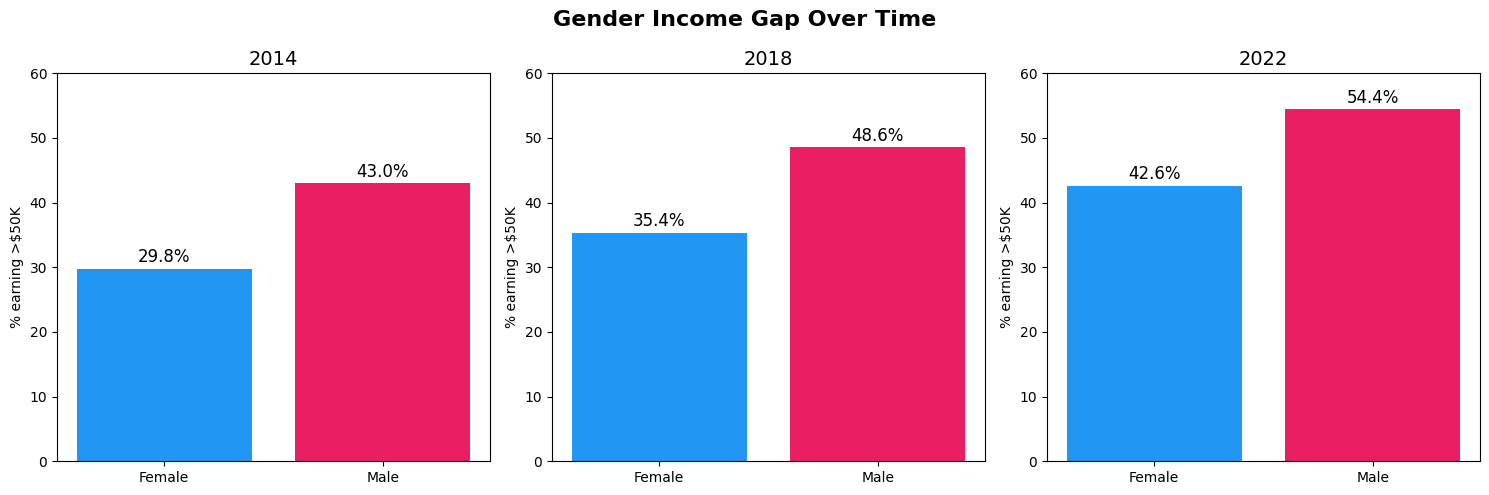

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, year in enumerate([2014, 2018, 2022]):
    df = datasets[year]
    rates = df.groupby('SEX_label')['income_over_50k'].mean() * 100
    axes[i].bar(rates.index, rates.values, color=['#2196F3', '#E91E63'])
    axes[i].set_title(f'{year}', fontsize=14)
    axes[i].set_ylabel('% earning >$50K')
    axes[i].set_ylim(0, 60)
    for j, v in enumerate(rates.values):
        axes[i].text(j, v + 1, f'{v:.1f}%', ha='center', fontsize=12)

fig.suptitle('Gender Income Gap Over Time', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('gender_income_gap.png', dpi=150, bbox_inches='tight')
plt.show()

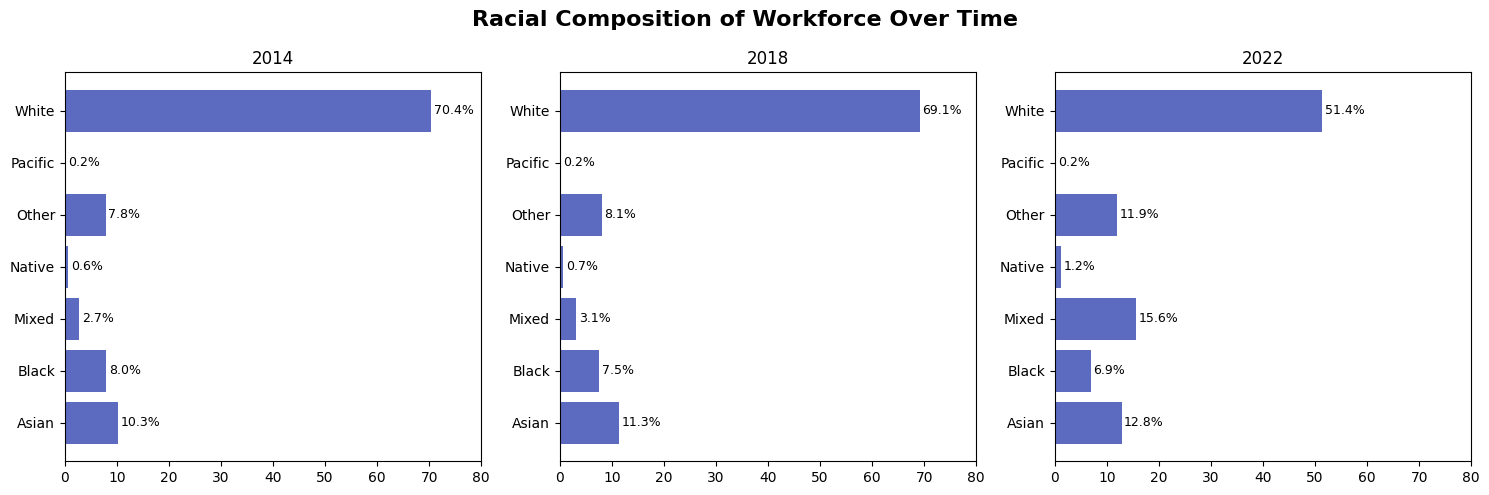

In [16]:
race_map = {
    1: 'White', 2: 'Black', 3: 'Native', 4: 'Native',
    5: 'Native', 6: 'Asian', 7: 'Pacific', 8: 'Other', 9: 'Mixed'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, year in enumerate([2014, 2018, 2022]):
    df = datasets[year].copy()
    df['Race'] = df['RAC1P'].map(race_map)
    counts = df['Race'].value_counts(normalize=True).sort_index() * 100
    axes[i].barh(counts.index, counts.values, color='#5C6BC0')
    axes[i].set_title(f'{year}')
    axes[i].set_xlim(0, 80)
    for j, v in enumerate(counts.values):
        axes[i].text(v + 0.5, j, f'{v:.1f}%', va='center', fontsize=9)

fig.suptitle('Racial Composition of Workforce Over Time', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('race_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

feature_cols = ['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'WKHP', 'SEX', 'RAC1P']

models = {}
splits = {}  # store train/test splits for later use

results = []

for year in [2014, 2018, 2022]:
    df = datasets[year]
    X = df[feature_cols]
    y = df['income_over_50k']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    print(f"Training RandomForest for {year}... ({len(X_train):,} train, {len(X_test):,} test)")
    
    model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    
    models[year] = model
    splits[year] = (X_train, X_test, y_train, y_test, y_pred)
    results.append({'Year': year, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

results_df = pd.DataFrame(results)
print("\n")
print(results_df.to_string(index=False))

Training RandomForest for 2014... (288,045 train, 123,448 test)
  Accuracy: 0.8175 | Precision: 0.7665 | Recall: 0.7235 | F1: 0.7443
Training RandomForest for 2018... (304,227 train, 130,383 test)
  Accuracy: 0.8097 | Precision: 0.7786 | Recall: 0.7684 | F1: 0.7735
Training RandomForest for 2022... (317,212 train, 135,949 test)
  Accuracy: 0.8017 | Precision: 0.7918 | Recall: 0.8055 | F1: 0.7986


 Year  Accuracy  Precision   Recall       F1
 2014  0.817502   0.766459 0.723462 0.744340
 2018  0.809668   0.778615 0.768391 0.773469
 2022  0.801734   0.791793 0.805472 0.798574


In [18]:
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference

fairness_results = []

for year in [2014, 2018, 2022]:
    X_train, X_test, y_train, y_test, y_pred = splits[year]
    
    sensitive_sex = X_test['SEX'].map({1: 'Male', 2: 'Female'})
    
    # Demographic parity difference
    dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_sex)
    
    # Equalized odds difference
    eod = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_sex)
    
    # Per-group metrics
    mf = MetricFrame(
        metrics={'accuracy': accuracy_score, 'precision': precision_score, 'recall': recall_score},
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive_sex
    )
    
    print(f"\n{'='*50}")
    print(f"  FAIRNESS ANALYSIS — {year}")
    print(f"{'='*50}")
    print(f"Demographic Parity Difference: {dpd:.4f}")
    print(f"Equalized Odds Difference:     {eod:.4f}")
    print(f"\nPer-group metrics:")
    print(mf.by_group.to_string())
    
    fairness_results.append({
        'Year': year,
        'Demographic Parity Diff': dpd,
        'Equalized Odds Diff': eod,
    })

fairness_df = pd.DataFrame(fairness_results)
print(f"\n\n{'='*50}")
print("FAIRNESS SUMMARY ACROSS YEARS")
print(f"{'='*50}")
print(fairness_df.to_string(index=False))


  FAIRNESS ANALYSIS — 2014
Demographic Parity Difference: 0.1649
Equalized Odds Difference:     0.1077

Per-group metrics:
        accuracy  precision    recall
SEX                                  
Female  0.833422   0.750363  0.656860
Male    0.803238   0.775278  0.764574

  FAIRNESS ANALYSIS — 2018
Demographic Parity Difference: 0.1548
Equalized Odds Difference:     0.0780

Per-group metrics:
        accuracy  precision    recall
SEX                                  
Female  0.820429   0.758896  0.721473
Male    0.799883   0.790893  0.799451

  FAIRNESS ANALYSIS — 2022
Demographic Parity Difference: 0.1470
Equalized Odds Difference:     0.0891

Per-group metrics:
        accuracy  precision    recall
SEX                                  
Female  0.809827   0.780132  0.769875
Male    0.794302   0.799726  0.830970


FAIRNESS SUMMARY ACROSS YEARS
 Year  Demographic Parity Diff  Equalized Odds Diff
 2014                 0.164944             0.107713
 2018                 0.154848      

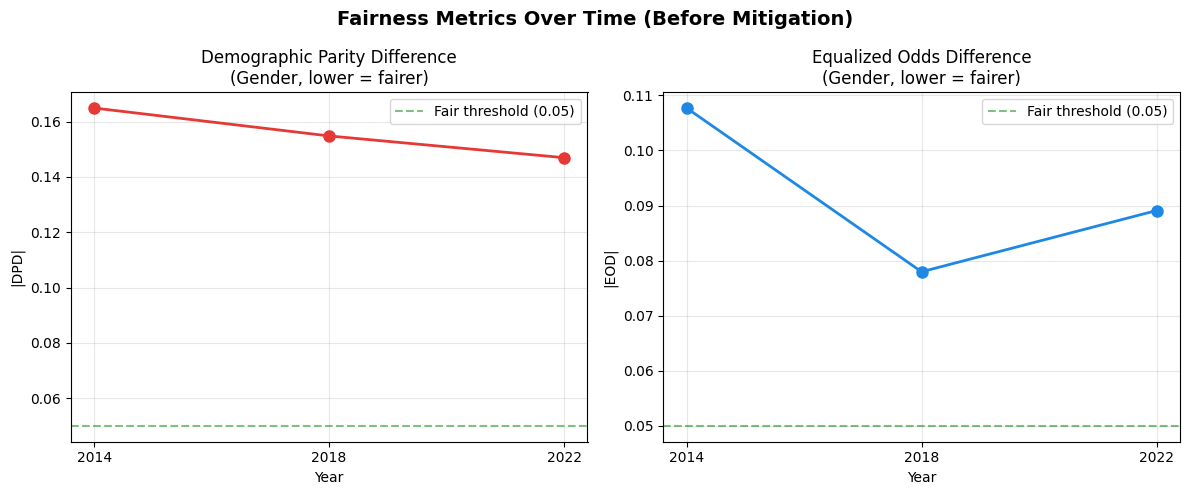

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

years = [2014, 2018, 2022]

# Demographic Parity Difference
axes[0].plot(years, fairness_df['Demographic Parity Diff'].abs(), 'o-', color='#E53935', linewidth=2, markersize=8)
axes[0].set_title('Demographic Parity Difference\n(Gender, lower = fairer)', fontsize=12)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('|DPD|')
axes[0].set_xticks(years)
axes[0].axhline(y=0.05, color='green', linestyle='--', alpha=0.5, label='Fair threshold (0.05)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Equalized Odds Difference
axes[1].plot(years, fairness_df['Equalized Odds Diff'].abs(), 'o-', color='#1E88E5', linewidth=2, markersize=8)
axes[1].set_title('Equalized Odds Difference\n(Gender, lower = fairer)', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('|EOD|')
axes[1].set_xticks(years)
axes[1].axhline(y=0.05, color='green', linestyle='--', alpha=0.5, label='Fair threshold (0.05)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Fairness Metrics Over Time (Before Mitigation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fairness_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
from fairlearn.postprocessing import ThresholdOptimizer

mitigated_results = []

for year in [2014, 2018, 2022]:
    X_train, X_test, y_train, y_test, y_pred_orig = splits[year]
    model = models[year]
    
    sensitive_train = X_train['SEX'].map({1: 'Male', 2: 'Female'})
    sensitive_test = X_test['SEX'].map({1: 'Male', 2: 'Female'})
    
    # Fit ThresholdOptimizer for equalized odds
    to = ThresholdOptimizer(
        estimator=model,
        constraints="equalized_odds",
        prefit=True,
        predict_method='predict_proba'
    )
    to.fit(X_train, y_train, sensitive_features=sensitive_train)
    y_pred_mitigated = to.predict(X_test, sensitive_features=sensitive_test)
    
    # Metrics after mitigation
    acc = accuracy_score(y_test, y_pred_mitigated)
    prec = precision_score(y_test, y_pred_mitigated)
    rec = recall_score(y_test, y_pred_mitigated)
    f1 = f1_score(y_test, y_pred_mitigated)
    dpd = demographic_parity_difference(y_test, y_pred_mitigated, sensitive_features=sensitive_test)
    eod = equalized_odds_difference(y_test, y_pred_mitigated, sensitive_features=sensitive_test)
    
    mf = MetricFrame(
        metrics={'accuracy': accuracy_score, 'recall': recall_score},
        y_true=y_test,
        y_pred=y_pred_mitigated,
        sensitive_features=sensitive_test
    )
    
    print(f"\n{'='*50}")
    print(f"  AFTER MITIGATION — {year}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")
    print(f"Demographic Parity Diff: {dpd:.4f}")
    print(f"Equalized Odds Diff:     {eod:.4f}")
    print(f"Per-group:")
    print(mf.by_group.to_string())
    
    mitigated_results.append({
        'Year': year, 'Accuracy': acc, 'F1': f1,
        'DPD': dpd, 'EOD': eod
    })

mitigated_df = pd.DataFrame(mitigated_results)


  AFTER MITIGATION — 2014
Accuracy: 0.8087 | F1: 0.7377
Demographic Parity Diff: 0.0890
Equalized Odds Diff:     0.0218
Per-group:
        accuracy    recall
SEX                       
Female  0.814772  0.719165
Male    0.803299  0.740992

  AFTER MITIGATION — 2018
Accuracy: 0.8006 | F1: 0.7617
Demographic Parity Diff: 0.0801
Equalized Odds Diff:     0.0083
Per-group:
        accuracy    recall
SEX                       
Female  0.803907  0.748748
Male    0.797613  0.757009

  AFTER MITIGATION — 2022
Accuracy: 0.7938 | F1: 0.7910
Demographic Parity Diff: 0.0741
Equalized Odds Diff:     0.0042
Per-group:
        accuracy    recall
SEX                       
Female  0.792865  0.797183
Male    0.794640  0.801345


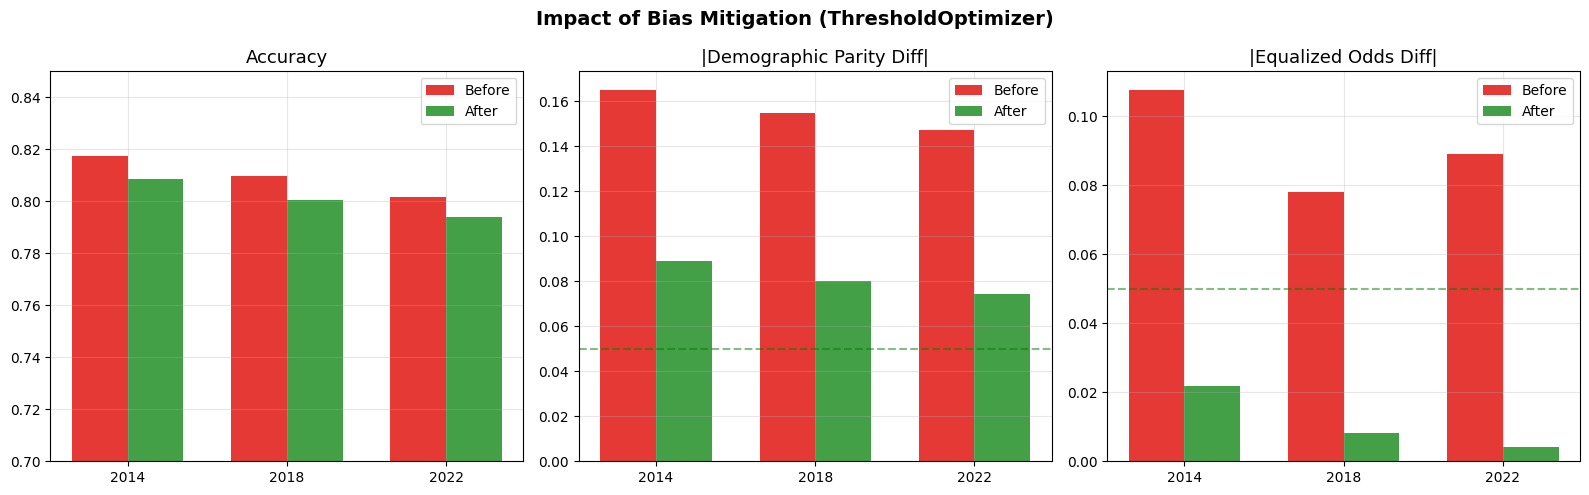

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
years = [2014, 2018, 2022]
x = np.arange(len(years))
w = 0.35

# Accuracy comparison
before_acc = results_df['Accuracy'].values
after_acc = mitigated_df['Accuracy'].values
axes[0].bar(x - w/2, before_acc, w, label='Before', color='#E53935')
axes[0].bar(x + w/2, after_acc, w, label='After', color='#43A047')
axes[0].set_title('Accuracy', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(years)
axes[0].set_ylim(0.7, 0.85)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DPD comparison
before_dpd = fairness_df['Demographic Parity Diff'].abs().values
after_dpd = mitigated_df['DPD'].abs().values
axes[1].bar(x - w/2, before_dpd, w, label='Before', color='#E53935')
axes[1].bar(x + w/2, after_dpd, w, label='After', color='#43A047')
axes[1].set_title('|Demographic Parity Diff|', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(years)
axes[1].axhline(y=0.05, color='green', linestyle='--', alpha=0.5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# EOD comparison
before_eod = fairness_df['Equalized Odds Diff'].abs().values
after_eod = mitigated_df['EOD'].abs().values
axes[2].bar(x - w/2, before_eod, w, label='Before', color='#E53935')
axes[2].bar(x + w/2, after_eod, w, label='After', color='#43A047')
axes[2].set_title('|Equalized Odds Diff|', fontsize=13)
axes[2].set_xticks(x)
axes[2].set_xticklabels(years)
axes[2].axhline(y=0.05, color='green', linestyle='--', alpha=0.5)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle('Impact of Bias Mitigation (ThresholdOptimizer)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('before_after_mitigation.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
import shap

shap_values_dict = {}

for year in [2014, 2018, 2022]:
    X_train, X_test, y_train, y_test, y_pred = splits[year]
    model = models[year]
    
    # Use a subsample for speed
    X_sample = X_test.sample(n=2000, random_state=42)
    
    print(f"Computing SHAP for {year}...")
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_sample)
    
    # sv[1] = SHAP values for positive class (income > 50k)
    shap_values_dict[year] = (sv[1], X_sample)
    print(f"  {year} done!")

print("\nAll SHAP values computed!")

Computing SHAP for 2014...
  2014 done!
Computing SHAP for 2018...
  2018 done!
Computing SHAP for 2022...
  2022 done!

All SHAP values computed!


In [25]:
# First let's check the shape
year = 2014
sv, X_sample = shap_values_dict[year]
print(f"SHAP values shape: {np.array(sv).shape}")
print(f"X_sample shape: {X_sample.shape}")

SHAP values shape: (9, 2)
X_sample shape: (2000, 9)


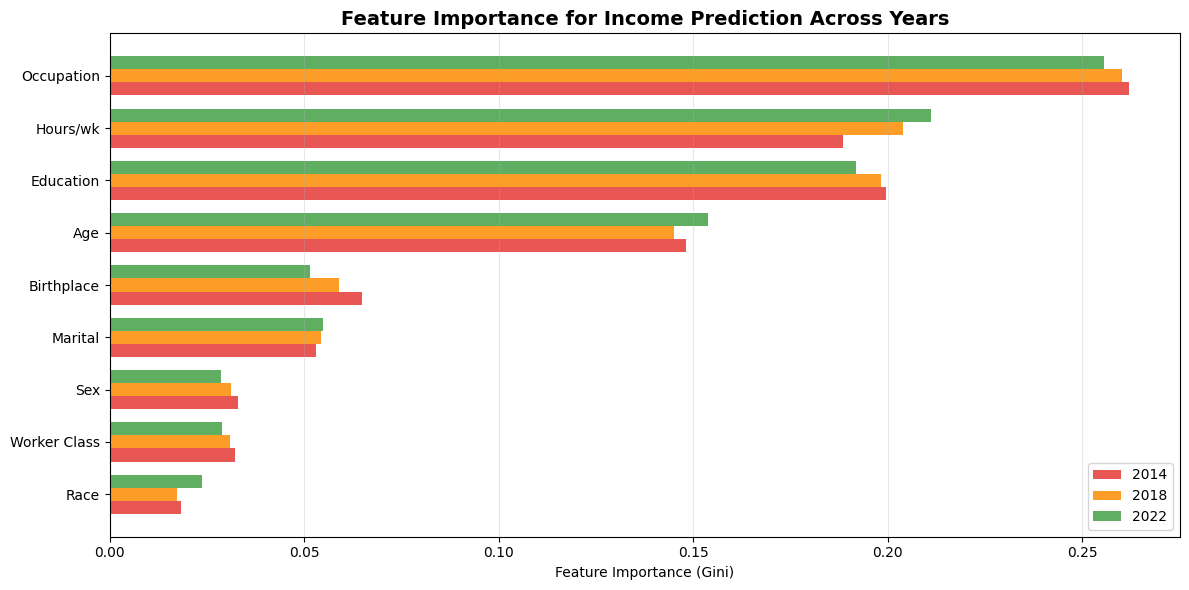

In [26]:
rename = {'RAC1P':'Race', 'AGEP':'Age', 'SCHL':'Education',
          'WKHP':'Hours/wk', 'OCCP':'Occupation', 'MAR':'Marital',
          'COW':'Worker Class', 'SEX':'Sex', 'POBP':'Birthplace'}

feature_cols = ['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'WKHP', 'SEX', 'RAC1P']

importance_data = []
for year in [2014, 2018, 2022]:
    importances = models[year].feature_importances_
    for j, col in enumerate(feature_cols):
        importance_data.append({
            'Year': year,
            'Feature': rename[col],
            'Importance': importances[j]
        })

imp_df = pd.DataFrame(importance_data)
features_order = imp_df.groupby('Feature')['Importance'].mean().sort_values(ascending=True).index

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.25
y_pos = np.arange(len(features_order))

for i, (year, color) in enumerate(zip([2014, 2018, 2022], ['#E53935', '#FB8C00', '#43A047'])):
    subset = imp_df[imp_df['Year'] == year].set_index('Feature').loc[features_order]
    ax.barh(y_pos + i * bar_width, subset['Importance'].values, bar_width,
            label=str(year), color=color, alpha=0.85)

ax.set_yticks(y_pos + bar_width)
ax.set_yticklabels(features_order)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance for Income Prediction Across Years', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

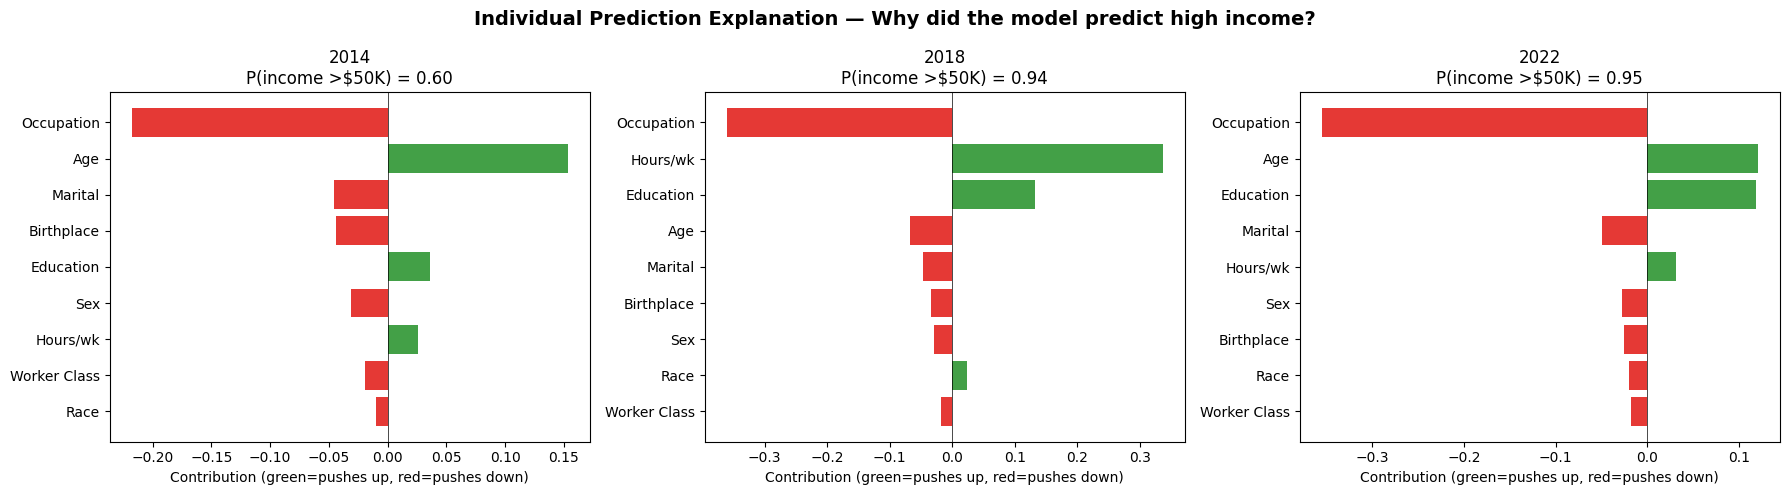

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, year in enumerate([2014, 2018, 2022]):
    X_train, X_test, y_train, y_test, y_pred = splits[year]
    model = models[year]
    
    high_income_idx = X_test[y_pred == 1].sample(1, random_state=42).index[0]
    person = X_test.loc[high_income_idx]
    
    proba = model.predict_proba(person.values.reshape(1, -1))[0]
    
    feat_means = X_train.mean().values.copy()
    feat_std = X_train.std().values.copy()
    feat_std[feat_std == 0] = 1
    person_vals = person.values.copy()
    
    deviations = (person_vals - feat_means) / feat_std
    contributions = deviations * model.feature_importances_
    
    rename = {'RAC1P':'Race', 'AGEP':'Age', 'SCHL':'Education',
              'WKHP':'Hours/wk', 'OCCP':'Occupation', 'MAR':'Marital',
              'COW':'Worker Class', 'SEX':'Sex', 'POBP':'Birthplace'}
    
    labels = [rename[c] for c in feature_cols]
    colors = ['#43A047' if c > 0 else '#E53935' for c in contributions]
    
    sorted_idx = np.argsort(np.abs(contributions))
    axes[i].barh(
        [labels[j] for j in sorted_idx],
        [contributions[j] for j in sorted_idx],
        color=[colors[j] for j in sorted_idx]
    )
    axes[i].set_title(f'{year}\nP(income >$50K) = {proba[1]:.2f}', fontsize=12)
    axes[i].axvline(x=0, color='black', linewidth=0.5)
    axes[i].set_xlabel('Contribution (green=pushes up, red=pushes down)')

fig.suptitle('Individual Prediction Explanation — Why did the model predict high income?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('individual_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# First let's check the shape
year = 2014
sv, X_sample = shap_values_dict[year]
print(f"SHAP values shape: {np.array(sv).shape}")
print(f"X_sample shape: {X_sample.shape}")

SHAP values shape: (9, 2)
X_sample shape: (2000, 9)


In [31]:
print("=" * 70)
print("TRADE-OFF ANALYSIS: ACCURACY vs FAIRNESS")
print("=" * 70)

tradeoff_data = []
for i, year in enumerate([2014, 2018, 2022]):
    b_acc = results_df.iloc[i]['Accuracy']
    a_acc = mitigated_df.iloc[i]['Accuracy']
    b_dpd = abs(fairness_df.iloc[i]['Demographic Parity Diff'])
    a_dpd = abs(mitigated_df.iloc[i]['DPD'])
    b_eod = abs(fairness_df.iloc[i]['Equalized Odds Diff'])
    a_eod = abs(mitigated_df.iloc[i]['EOD'])
    
    tradeoff_data.append({
        'Year': year,
        'Acc (Before)': f'{b_acc:.4f}',
        'Acc (After)': f'{a_acc:.4f}',
        'Acc Cost': f'{(b_acc - a_acc)*100:.2f}%',
        'DPD (Before)': f'{b_dpd:.4f}',
        'DPD (After)': f'{a_dpd:.4f}',
        'DPD Improvement': f'{(b_dpd - a_dpd)*100:.2f}%',
        'EOD (Before)': f'{b_eod:.4f}',
        'EOD (After)': f'{a_eod:.4f}',
        'EOD Improvement': f'{(b_eod - a_eod)*100:.2f}%',
    })

for row in tradeoff_data:
    print(f"\n--- {row['Year']} ---")
    print(f"  Accuracy:  {row['Acc (Before)']} → {row['Acc (After)']}  (cost: {row['Acc Cost']})")
    print(f"  DPD:       {row['DPD (Before)']} → {row['DPD (After)']}  (improved: {row['DPD Improvement']})")
    print(f"  EOD:       {row['EOD (Before)']} → {row['EOD (After)']}  (improved: {row['EOD Improvement']})")

TRADE-OFF ANALYSIS: ACCURACY vs FAIRNESS

--- 2014 ---
  Accuracy:  0.8175 → 0.8087  (cost: 0.88%)
  DPD:       0.1649 → 0.0890  (improved: 7.60%)
  EOD:       0.1077 → 0.0218  (improved: 8.59%)

--- 2018 ---
  Accuracy:  0.8097 → 0.8006  (cost: 0.91%)
  DPD:       0.1548 → 0.0801  (improved: 7.48%)
  EOD:       0.0780 → 0.0083  (improved: 6.97%)

--- 2022 ---
  Accuracy:  0.8017 → 0.7938  (cost: 0.79%)
  DPD:       0.1470 → 0.0741  (improved: 7.28%)
  EOD:       0.0891 → 0.0042  (improved: 8.49%)


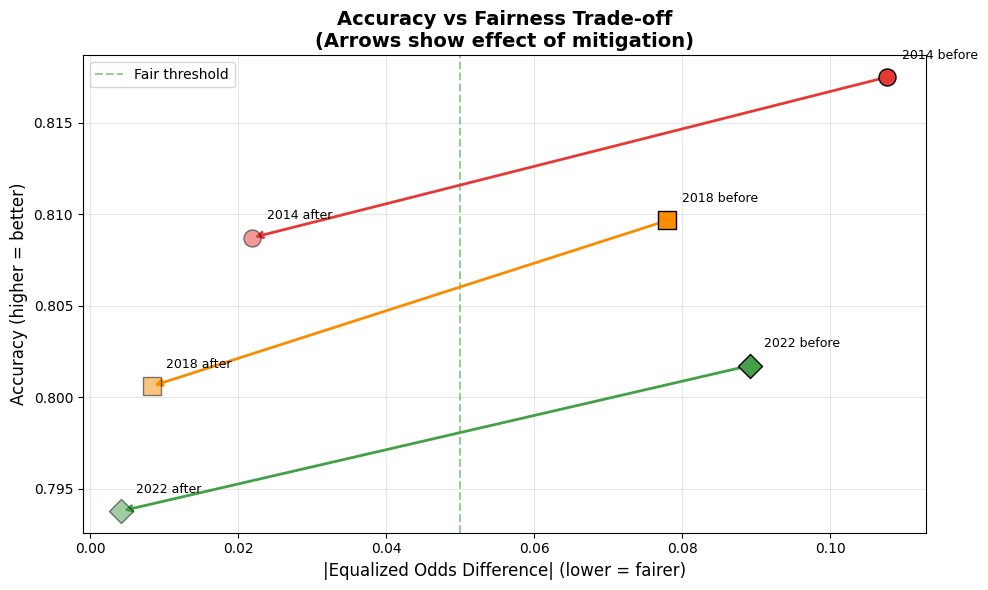

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

for year, color, marker in zip([2014, 2018, 2022], ['#E53935', '#FB8C00', '#43A047'], ['o', 's', 'D']):
    i = [2014, 2018, 2022].index(year)
    
    b_acc = results_df.iloc[i]['Accuracy']
    a_acc = mitigated_df.iloc[i]['Accuracy']
    b_eod = abs(fairness_df.iloc[i]['Equalized Odds Diff'])
    a_eod = abs(mitigated_df.iloc[i]['EOD'])
    
    # Before mitigation
    ax.scatter(b_eod, b_acc, color=color, marker=marker, s=150, edgecolors='black', zorder=5)
    # After mitigation
    ax.scatter(a_eod, a_acc, color=color, marker=marker, s=150, edgecolors='black', zorder=5, alpha=0.5)
    # Arrow from before to after
    ax.annotate('', xy=(a_eod, a_acc), xytext=(b_eod, b_acc),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    # Labels
    ax.annotate(f'{year} before', (b_eod + 0.002, b_acc + 0.001), fontsize=9)
    ax.annotate(f'{year} after', (a_eod + 0.002, a_acc + 0.001), fontsize=9)

ax.set_xlabel('|Equalized Odds Difference| (lower = fairer)', fontsize=12)
ax.set_ylabel('Accuracy (higher = better)', fontsize=12)
ax.set_title('Accuracy vs Fairness Trade-off\n(Arrows show effect of mitigation)', fontsize=14, fontweight='bold')
ax.axvline(x=0.05, color='green', linestyle='--', alpha=0.4, label='Fair threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_vs_fairness_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
race_map = {1: 'White', 2: 'Black', 3: 'Native', 4: 'Native',
            5: 'Native', 6: 'Asian', 7: 'Pacific', 8: 'Other', 9: 'Mixed'}

print("=" * 60)
print("FAIRNESS ANALYSIS BY RACE (Before Mitigation)")
print("=" * 60)

for year in [2014, 2018, 2022]:
    X_train, X_test, y_train, y_test, y_pred = splits[year]
    
    sensitive_race = X_test['RAC1P'].map(race_map)
    
    mf = MetricFrame(
        metrics={
            'accuracy': accuracy_score,
            'recall': recall_score,
            'selection_rate': lambda y_t, y_p: np.mean(y_p),
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive_race
    )
    
    dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_race)
    eod = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_race)
    
    print(f"\n--- {year} ---")
    print(f"DPD (race): {dpd:.4f} | EOD (race): {eod:.4f}")
    print(mf.by_group.round(4).to_string())

FAIRNESS ANALYSIS BY RACE (Before Mitigation)

--- 2014 ---
DPD (race): 0.3249 | EOD (race): 0.3868
         accuracy  recall  selection_rate
RAC1P                                    
Asian      0.8206  0.7739          0.4129
Black      0.8247  0.6031          0.2336
Mixed      0.8236  0.6296          0.2549
Native     0.8256  0.6000          0.2196
Other      0.8755  0.3871          0.0880
Pacific    0.8085  0.5625          0.2255
White      0.8095  0.7443          0.3835

--- 2018 ---
DPD (race): 0.3565 | EOD (race): 0.3773
         accuracy  recall  selection_rate
RAC1P                                    
Asian      0.8213  0.8227          0.4964
Black      0.7952  0.6494          0.3039
Mixed      0.8320  0.7488          0.3490
Native     0.8015  0.5896          0.2481
Other      0.8365  0.4455          0.1399
Pacific    0.7331  0.5488          0.3008
White      0.8054  0.7886          0.4543

--- 2022 ---
DPD (race): 0.3619 | EOD (race): 0.3076
         accuracy  recall  selection

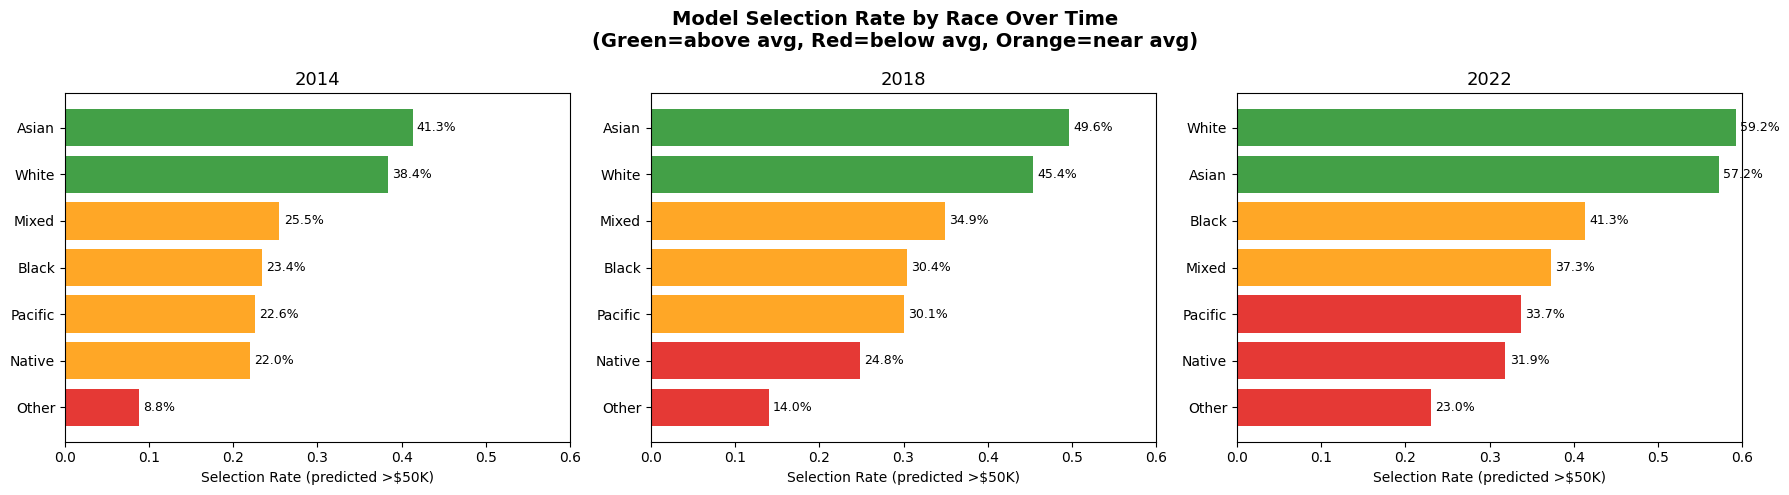

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, year in enumerate([2014, 2018, 2022]):
    X_train, X_test, y_train, y_test, y_pred = splits[year]
    
    df_temp = X_test.copy()
    df_temp['Race'] = df_temp['RAC1P'].map(race_map)
    df_temp['predicted_high'] = y_pred
    
    rates = df_temp.groupby('Race')['predicted_high'].mean().sort_values()
    
    colors = ['#E53935' if v < rates.mean() - 0.05 else '#43A047' if v > rates.mean() + 0.05 else '#FFA726' for v in rates.values]
    
    axes[i].barh(rates.index, rates.values, color=colors)
    axes[i].set_title(f'{year}', fontsize=13)
    axes[i].set_xlabel('Selection Rate (predicted >$50K)')
    axes[i].set_xlim(0, 0.6)
    for j, v in enumerate(rates.values):
        axes[i].text(v + 0.005, j, f'{v:.1%}', va='center', fontsize=9)

fig.suptitle('Model Selection Rate by Race Over Time\n(Green=above avg, Red=below avg, Orange=near avg)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('race_selection_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
print("=" * 60)
print("RACE-BASED BIAS MITIGATION")
print("=" * 60)

race_mitigated_results = []

for year in [2014, 2018, 2022]:
    X_train, X_test, y_train, y_test, y_pred_orig = splits[year]
    model = models[year]
    
    sensitive_train = X_train['RAC1P'].map(race_map)
    sensitive_test = X_test['RAC1P'].map(race_map)
    
    to = ThresholdOptimizer(
        estimator=model,
        constraints="equalized_odds",
        prefit=True,
        predict_method='predict_proba'
    )
    to.fit(X_train, y_train, sensitive_features=sensitive_train)
    y_pred_mit = to.predict(X_test, sensitive_features=sensitive_test)
    
    acc_before = accuracy_score(y_test, y_pred_orig)
    acc_after = accuracy_score(y_test, y_pred_mit)
    dpd_before = abs(demographic_parity_difference(y_test, y_pred_orig, sensitive_features=sensitive_test))
    dpd_after = abs(demographic_parity_difference(y_test, y_pred_mit, sensitive_features=sensitive_test))
    eod_before = abs(equalized_odds_difference(y_test, y_pred_orig, sensitive_features=sensitive_test))
    eod_after = abs(equalized_odds_difference(y_test, y_pred_mit, sensitive_features=sensitive_test))
    
    print(f"\n--- {year} ---")
    print(f"  Accuracy:  {acc_before:.4f} → {acc_after:.4f}  (cost: {(acc_before-acc_after)*100:.2f}%)")
    print(f"  DPD:       {dpd_before:.4f} → {dpd_after:.4f}  (improved: {(dpd_before-dpd_after)*100:.2f}%)")
    print(f"  EOD:       {eod_before:.4f} → {eod_after:.4f}  (improved: {(eod_before-eod_after)*100:.2f}%)")
    
    race_mitigated_results.append({
        'Year': year,
        'Acc_before': acc_before, 'Acc_after': acc_after,
        'DPD_before': dpd_before, 'DPD_after': dpd_after,
        'EOD_before': eod_before, 'EOD_after': eod_after,
    })

race_mit_df = pd.DataFrame(race_mitigated_results)

RACE-BASED BIAS MITIGATION

--- 2014 ---
  Accuracy:  0.8175 → 0.8086  (cost: 0.89%)
  DPD:       0.3249 → 0.1770  (improved: 14.79%)
  EOD:       0.3868 → 0.1830  (improved: 20.37%)

--- 2018 ---
  Accuracy:  0.8097 → 0.8007  (cost: 0.89%)
  DPD:       0.3565 → 0.1845  (improved: 17.20%)
  EOD:       0.3773 → 0.1609  (improved: 21.64%)

--- 2022 ---
  Accuracy:  0.8017 → 0.7805  (cost: 2.12%)
  DPD:       0.3619 → 0.1707  (improved: 19.12%)
  EOD:       0.3076 → 0.0902  (improved: 21.73%)


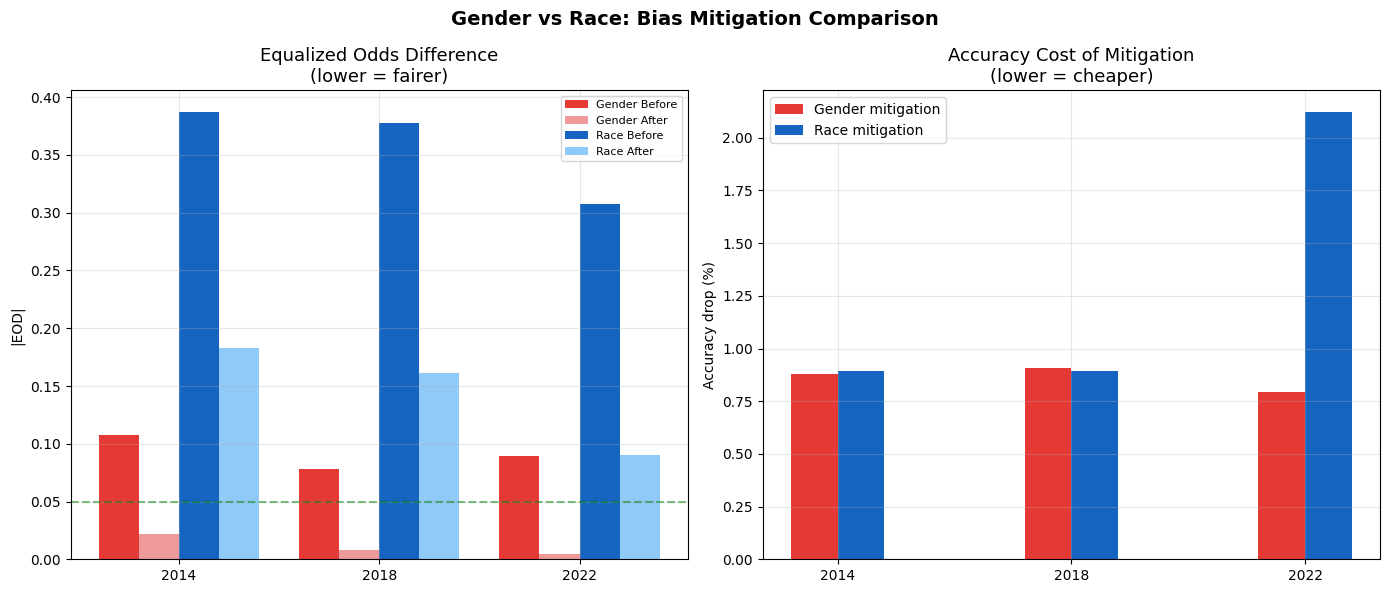

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
years = [2014, 2018, 2022]
x = np.arange(len(years))
w = 0.2

# EOD comparison — Gender
ax = axes[0]
ax.bar(x - 1.5*w, fairness_df['Equalized Odds Diff'].abs(), w, label='Gender Before', color='#E53935')
ax.bar(x - 0.5*w, mitigated_df['EOD'].abs(), w, label='Gender After', color='#EF9A9A')
ax.bar(x + 0.5*w, race_mit_df['EOD_before'], w, label='Race Before', color='#1565C0')
ax.bar(x + 1.5*w, race_mit_df['EOD_after'], w, label='Race After', color='#90CAF9')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_title('Equalized Odds Difference\n(lower = fairer)', fontsize=13)
ax.set_ylabel('|EOD|')
ax.axhline(y=0.05, color='green', linestyle='--', alpha=0.5)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Accuracy cost comparison
ax = axes[1]
gender_cost = [(results_df.iloc[i]['Accuracy'] - mitigated_df.iloc[i]['Accuracy'])*100 for i in range(3)]
race_cost = [(r['Acc_before'] - r['Acc_after'])*100 for _, r in race_mit_df.iterrows()]
ax.bar(x - w/2, gender_cost, w, label='Gender mitigation', color='#E53935')
ax.bar(x + w/2, race_cost, w, label='Race mitigation', color='#1565C0')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_title('Accuracy Cost of Mitigation\n(lower = cheaper)', fontsize=13)
ax.set_ylabel('Accuracy drop (%)')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('Gender vs Race: Bias Mitigation Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gender_vs_race_mitigation.png', dpi=150, bbox_inches='tight')
plt.show()

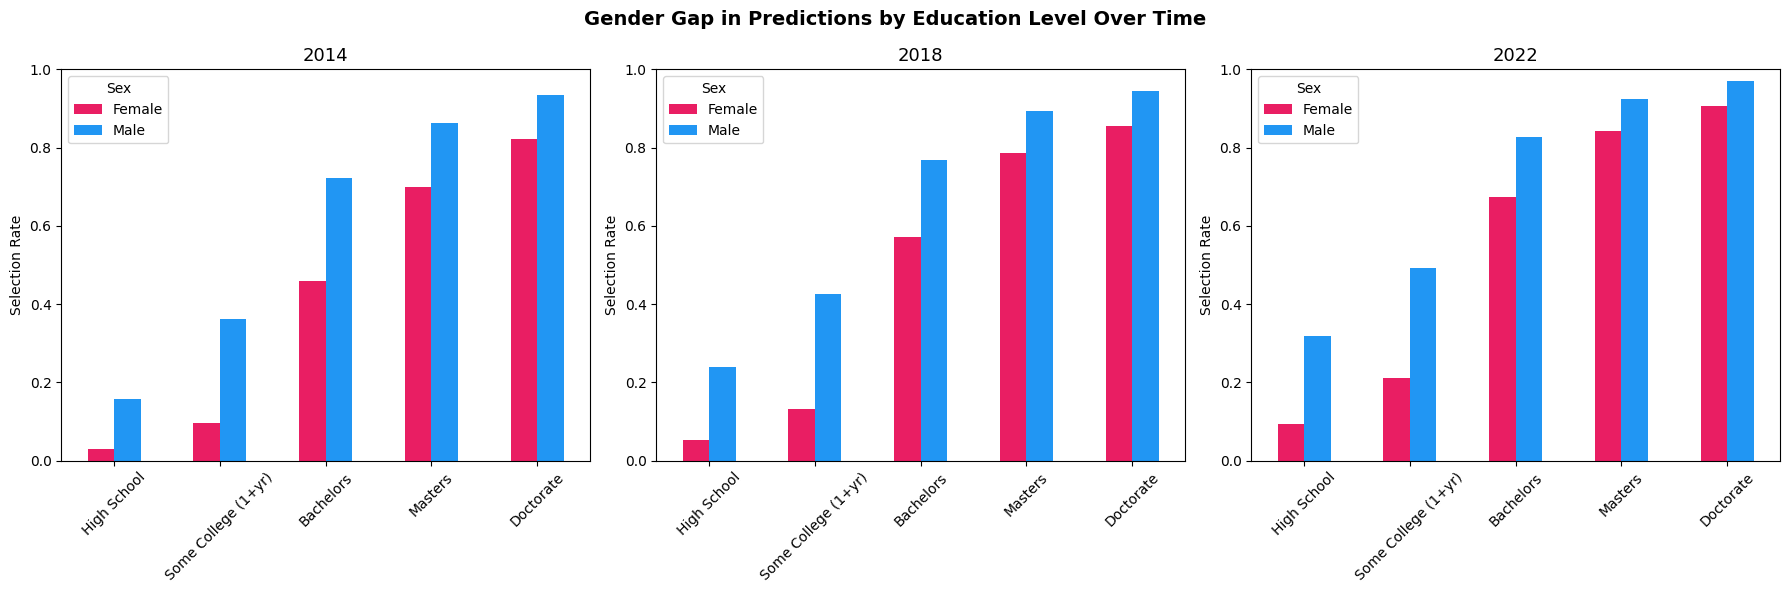

In [37]:
edu_map = {
    1: 'No school', 2: 'Preschool', 3: 'Kindergarten',
    4: 'Grade 1-4', 5: 'Grade 1-4', 6: 'Grade 1-4', 7: 'Grade 1-4',
    8: 'Grade 5-8', 9: 'Grade 5-8', 10: 'Grade 5-8', 11: 'Grade 5-8',
    12: 'Grade 9-12', 13: 'Grade 9-12', 14: 'Grade 9-12', 15: 'Grade 9-12',
    16: 'High School', 17: 'GED',
    18: 'Some College (<1yr)', 19: 'Some College (1+yr)', 20: 'Associates',
    21: 'Bachelors', 22: 'Masters', 23: 'Professional', 24: 'Doctorate'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, year in enumerate([2014, 2018, 2022]):
    X_train, X_test, y_train, y_test, y_pred = splits[year]
    df_temp = X_test.copy()
    df_temp['predicted'] = y_pred
    df_temp['actual'] = y_test.values
    df_temp['Sex'] = df_temp['SEX'].map({1: 'Male', 2: 'Female'})
    df_temp['Education'] = df_temp['SCHL'].map(edu_map)
    
    # Focus on common education levels
    keep_edu = ['High School', 'Some College (1+yr)', 'Bachelors', 'Masters', 'Doctorate']
    df_temp = df_temp[df_temp['Education'].isin(keep_edu)]
    
    pivot = df_temp.groupby(['Education', 'Sex'])['predicted'].mean().unstack()
    pivot = pivot.loc[keep_edu]  # order
    
    pivot.plot(kind='bar', ax=axes[i], color=['#E91E63', '#2196F3'])
    axes[i].set_title(f'{year}', fontsize=13)
    axes[i].set_ylabel('Selection Rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Sex')
    axes[i].set_ylim(0, 1.0)

fig.suptitle('Gender Gap in Predictions by Education Level Over Time',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('intersectional_gender_education.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
print("=" * 80)
print("COMPLETE SUMMARY TABLE FOR REPORT")
print("=" * 80)

print("\n1. MODEL PERFORMANCE")
print(results_df.to_string(index=False))

print("\n2. GENDER FAIRNESS (Before → After Mitigation)")
for i, year in enumerate([2014, 2018, 2022]):
    print(f"  {year}: DPD {abs(fairness_df.iloc[i]['Demographic Parity Diff']):.4f} → {abs(mitigated_df.iloc[i]['DPD']):.4f} | "
          f"EOD {abs(fairness_df.iloc[i]['Equalized Odds Diff']):.4f} → {abs(mitigated_df.iloc[i]['EOD']):.4f}")

print("\n3. RACE FAIRNESS (Before → After Mitigation)")
for i, year in enumerate([2014, 2018, 2022]):
    r = race_mit_df.iloc[i]
    print(f"  {year}: DPD {r['DPD_before']:.4f} → {r['DPD_after']:.4f} | "
          f"EOD {r['EOD_before']:.4f} → {r['EOD_after']:.4f}")

print("\n4. KEY FINDING: Accuracy cost of fairness")
for i, year in enumerate([2014, 2018, 2022]):
    g_cost = (results_df.iloc[i]['Accuracy'] - mitigated_df.iloc[i]['Accuracy']) * 100
    r_cost = (race_mit_df.iloc[i]['Acc_before'] - race_mit_df.iloc[i]['Acc_after']) * 100
    print(f"  {year}: Gender mitigation cost {g_cost:.2f}% | Race mitigation cost {r_cost:.2f}%")

COMPLETE SUMMARY TABLE FOR REPORT

1. MODEL PERFORMANCE
 Year  Accuracy  Precision   Recall       F1
 2014  0.817502   0.766459 0.723462 0.744340
 2018  0.809668   0.778615 0.768391 0.773469
 2022  0.801734   0.791793 0.805472 0.798574

2. GENDER FAIRNESS (Before → After Mitigation)
  2014: DPD 0.1649 → 0.0890 | EOD 0.1077 → 0.0218
  2018: DPD 0.1548 → 0.0801 | EOD 0.0780 → 0.0083
  2022: DPD 0.1470 → 0.0741 | EOD 0.0891 → 0.0042

3. RACE FAIRNESS (Before → After Mitigation)
  2014: DPD 0.3249 → 0.1770 | EOD 0.3868 → 0.1830
  2018: DPD 0.3565 → 0.1845 | EOD 0.3773 → 0.1609
  2022: DPD 0.3619 → 0.1707 | EOD 0.3076 → 0.0902

4. KEY FINDING: Accuracy cost of fairness
  2014: Gender mitigation cost 0.88% | Race mitigation cost 0.89%
  2018: Gender mitigation cost 0.91% | Race mitigation cost 0.89%
  2022: Gender mitigation cost 0.79% | Race mitigation cost 2.12%


In [40]:
sv = shap_values_dict[2014]
print(f"Type: {type(sv)}")
print(f"Length: {len(sv)}")
print(f"Type of sv[0]: {type(sv[0])}")
print(f"Shape of sv[0]: {np.array(sv[0]).shape}")
print(f"Shape of sv[1]: {np.array(sv[1]).shape}")

Type: <class 'tuple'>
Length: 2
Type of sv[0]: <class 'numpy.ndarray'>
Shape of sv[0]: (9, 2)
Shape of sv[1]: (2000, 9)


In [41]:
# Check what's actually stored
data = shap_values_dict[2014]
print(f"data[0] shape: {np.array(data[0]).shape if hasattr(data[0], 'shape') else 'inhomogeneous'}")
print(f"data[1] shape: {data[1].shape}")
print(f"data[1] columns: {data[1].columns.tolist() if hasattr(data[1], 'columns') else 'no columns'}")

data[0] shape: (9, 2)
data[1] shape: (2000, 9)
data[1] columns: ['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'WKHP', 'SEX', 'RAC1P']
